In [1]:
# HealthGuard AI - Diabetes Model Training
# Author: HealthGuard AI Team
# Date: 2026
# Version: 2.0 - Complete with Hyperparameter Tuning,
#                Cross Validation, ROC Curve, SHAP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report,
                             roc_curve, auc)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     StratifiedKFold)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8')

print("=" * 50)
print("  HealthGuard AI - Diabetes Model Training v2.0")
print("=" * 50)
print("Libraries Loaded Successfully!")

  HealthGuard AI - Diabetes Model Training v2.0
Libraries Loaded Successfully!


In [2]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'])

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [3]:
import sys
print(sys.executable)

E:\anaconda3\python.exe


In [4]:
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap'])

CompletedProcess(args=['E:\\anaconda3\\python.exe', '-m', 'pip', 'install', 'shap'], returncode=0)

In [5]:
import shap
print(shap.__version__)

0.52.0


In [6]:
# Load Cleaned Train and Test Data

X_train = pd.read_csv("E:/HealthGuard_AI/data/processed/diabetes_X_train.csv")
X_test = pd.read_csv("E:/HealthGuard_AI/data/processed/diabetes_X_test.csv")
y_train = pd.read_csv("E:/HealthGuard_AI/data/processed/diabetes_y_train.csv").values.ravel()
y_test = pd.read_csv("E:/HealthGuard_AI/data/processed/diabetes_y_test.csv").values.ravel()

print("Data Loaded Successfully!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")
print(f"\nTraining Class Distribution:")
print(f"No Diabetes: {(y_train==0).sum()}")
print(f"Diabetes: {(y_train==1).sum()}")

Data Loaded Successfully!
X_train Shape: (644, 8)
X_test Shape: (119, 8)
y_train Shape: (644,)
y_test Shape: (119,)

Training Class Distribution:
No Diabetes: 322
Diabetes: 322


STEP 1: CROSS VALIDATION (5-FOLD)
Cross Validation Results:
----------------------------------------

Logistic Regression:
  Mean F1: 0.8831
  Std F1:  0.0187
  Scores:  [0.8939 0.8788 0.8682 0.9134 0.8613]

Random Forest:
  Mean F1: 0.9283
  Std F1:  0.0121
  Scores:  [0.9323 0.9091 0.9219 0.9449 0.9333]

XGBoost:
  Mean F1: 0.9370
  Std F1:  0.0089
  Scores:  [0.9313 0.9449 0.9231 0.9385 0.9474]

SVM:
  Mean F1: 0.9113
  Std F1:  0.0210
  Scores:  [0.8939 0.9077 0.9077 0.9516 0.8955]

Neural Network:
  Mean F1: 0.9190
  Std F1:  0.0171
  Scores:  [0.9104 0.9231 0.8923 0.944  0.9254]


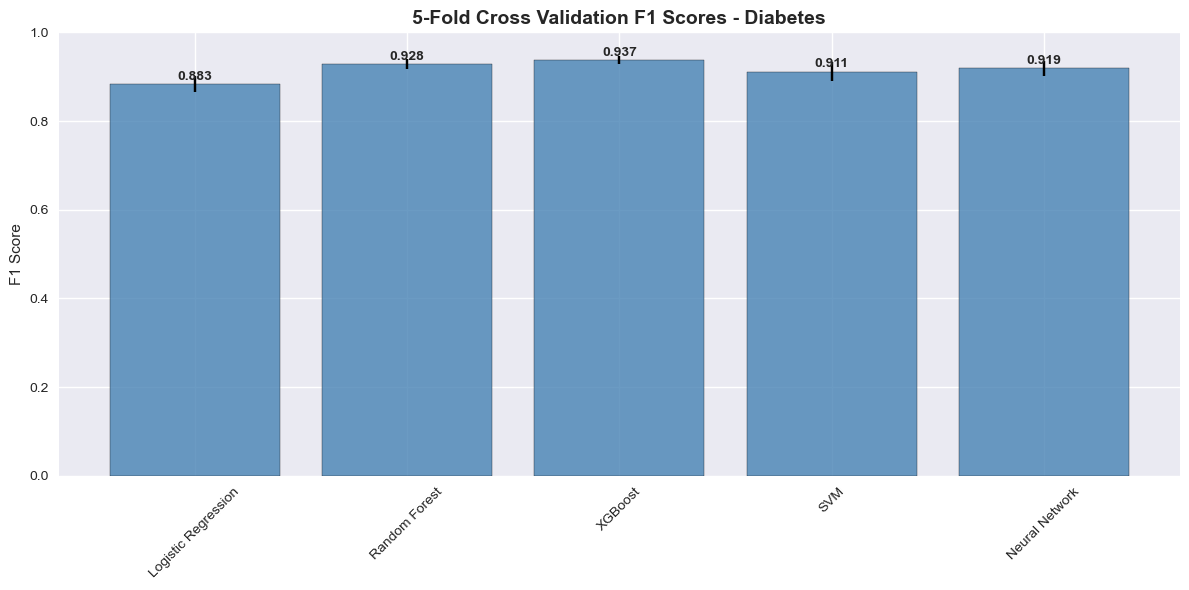


Cross Validation Complete!


In [7]:
# Step 1: Cross Validation
# 5-Fold Stratified Cross Validation
# Check model performance before hyperparameter tuning

print("=" * 50)
print("STEP 1: CROSS VALIDATION (5-FOLD)")
print("=" * 50)

cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=42,
                                              max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                           random_state=42),
    'XGBoost': XGBClassifier(random_state=42,
                              eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),
                                    max_iter=500,
                                    random_state=42)
}

cv_results = {}

print("Cross Validation Results:")
print("-" * 40)

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1')
    cv_results[name] = {
        'Mean F1': cv_scores.mean(),
        'Std F1': cv_scores.std(),
        'All Scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"  Mean F1: {cv_scores.mean():.4f}")
    print(f"  Std F1:  {cv_scores.std():.4f}")
    print(f"  Scores:  {cv_scores.round(4)}")

# Plot CV Results
plt.figure(figsize=(12, 6))
names = list(cv_results.keys())
means = [cv_results[n]['Mean F1'] for n in names]
stds = [cv_results[n]['Std F1'] for n in names]

bars = plt.bar(names, means, yerr=stds,
               color='steelblue', edgecolor='black',
               capsize=5, alpha=0.8)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontweight='bold')

plt.title('5-Fold Cross Validation F1 Scores - Diabetes',
          fontweight='bold', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCross Validation Complete!")

In [8]:
# Step 2: Hyperparameter Tuning
# GridSearchCV for best parameters

print("=" * 50)
print("STEP 2: HYPERPARAMETER TUNING")
print("=" * 50)

# Random Forest Tuning
print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF F1: {rf_grid.best_score_:.4f}")

# XGBoost Tuning
print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB F1: {xgb_grid.best_score_:.4f}")

print("\nHyperparameter Tuning Complete!")

STEP 2: HYPERPARAMETER TUNING
Tuning Random Forest...
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF F1: 0.9359

Tuning XGBoost...
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best XGB F1: 0.9531

Hyperparameter Tuning Complete!


In [9]:
# Step 3: Train All Models with Best Parameters

print("=" * 50)
print("STEP 3: TRAIN FINAL MODELS")
print("=" * 50)

final_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000),
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'SVM': SVC(probability=True, random_state=42, C=1.0),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500, random_state=42)
}

results = {}

for name, model in final_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC ROC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Model': model
    }

    print(f"Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"F1 Score:  {results[name]['F1 Score']:.4f}")
    print(f"AUC ROC:   {results[name]['AUC ROC']:.4f}")

print("\nAll Models Trained!")

STEP 3: TRAIN FINAL MODELS

Training Logistic Regression...
Accuracy:  0.8655
F1 Score:  0.8140
AUC ROC:   0.9340

Training Random Forest...
Accuracy:  0.8992
F1 Score:  0.8421
AUC ROC:   0.9628

Training XGBoost...
Accuracy:  0.8992
F1 Score:  0.8421
AUC ROC:   0.9545

Training SVM...
Accuracy:  0.8824
F1 Score:  0.8205
AUC ROC:   0.9159

Training Neural Network...
Accuracy:  0.8571
F1 Score:  0.7848
AUC ROC:   0.9061

All Models Trained!


STEP 4: MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.8655     0.7292  0.9211    0.8140   0.9340
Random Forest          0.8992     0.8421  0.8421    0.8421   0.9628
XGBoost                0.8992     0.8421  0.8421    0.8421   0.9545
SVM                    0.8824     0.8000  0.8421    0.8205   0.9159
Neural Network         0.8571     0.7561  0.8158    0.7848   0.9061


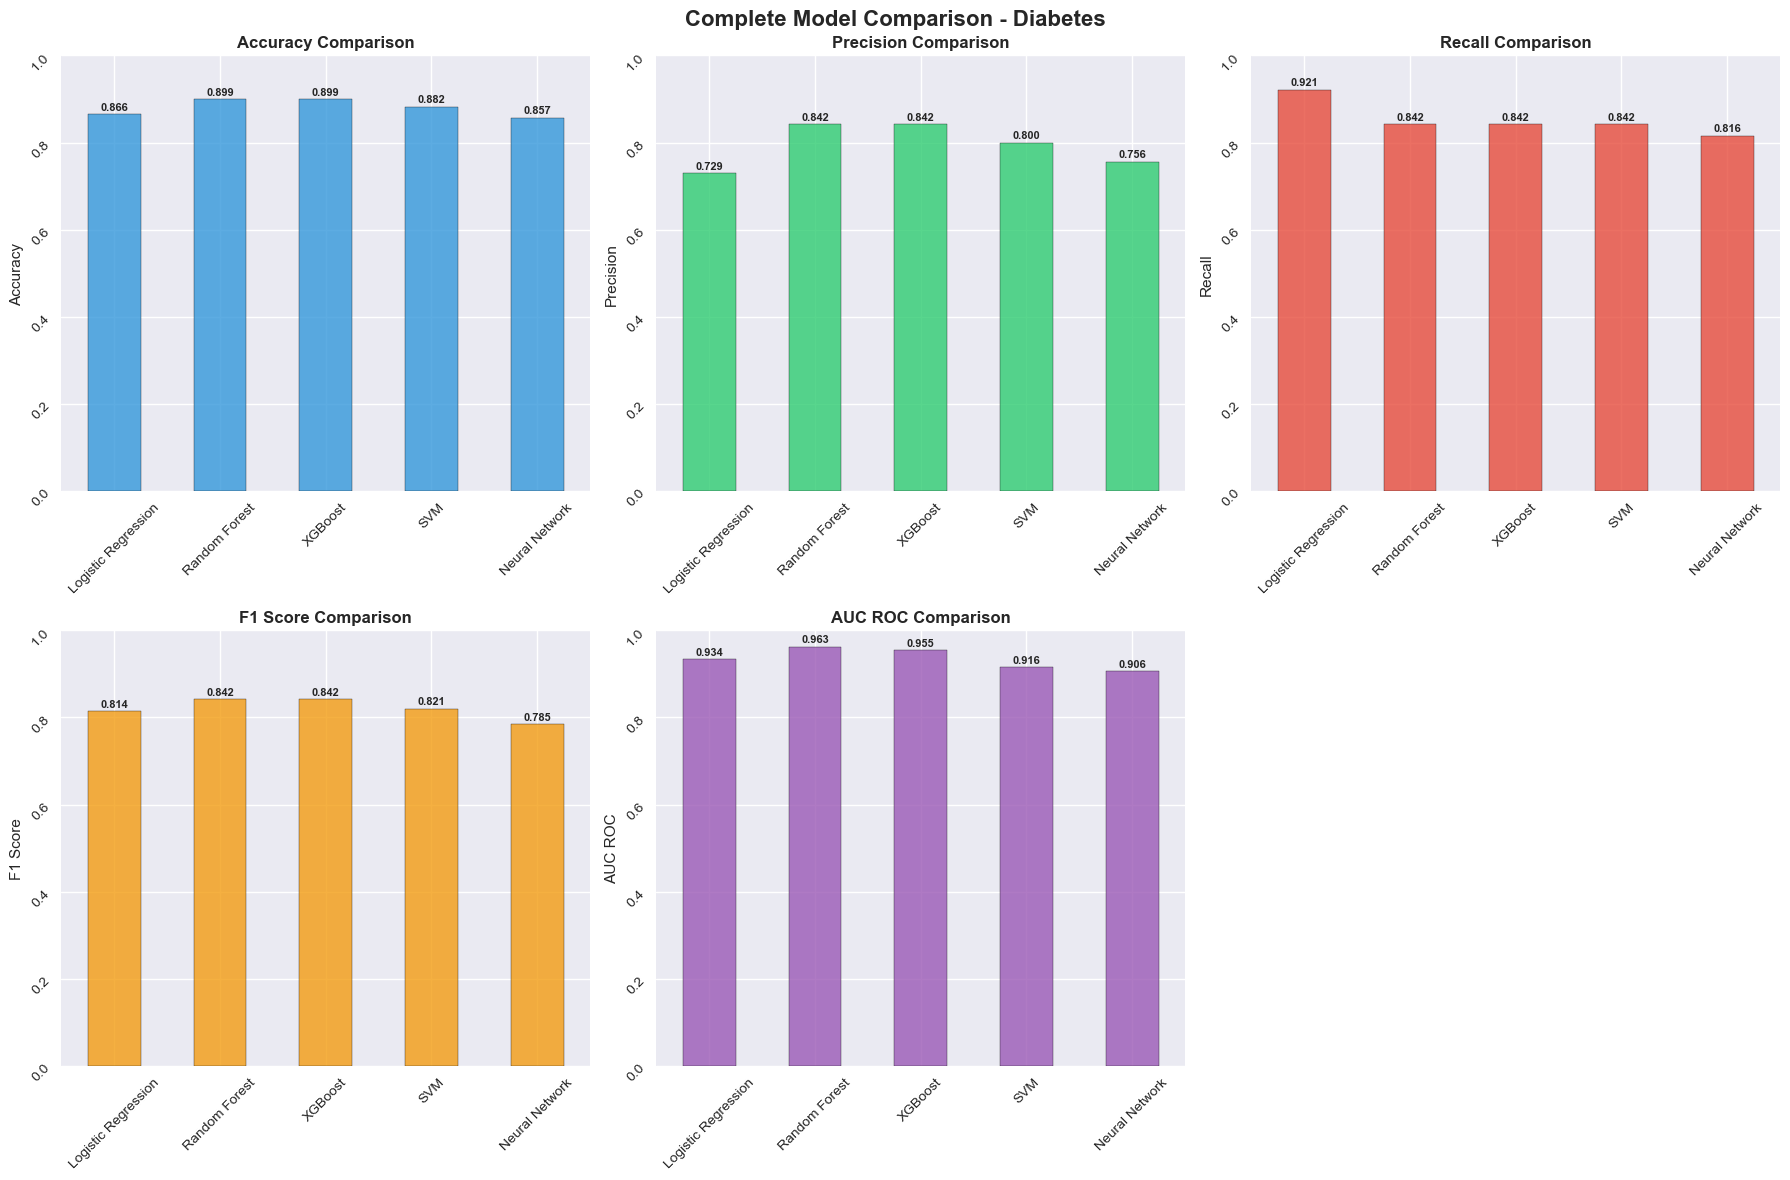

In [10]:
# Step 4: Compare All Models

print("=" * 50)
print("STEP 4: MODEL COMPARISON")
print("=" * 50)

results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['Accuracy'],
        'Precision': results[name]['Precision'],
        'Recall': results[name]['Recall'],
        'F1 Score': results[name]['F1 Score'],
        'AUC ROC': results[name]['AUC ROC']
    }
    for name in results
}).T.round(4)

print(results_df)

# Plot All Metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall',
           'F1 Score', 'AUC ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c',
          '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar',
                            ax=axes[i],
                            color=colors[i],
                            edgecolor='black',
                            alpha=0.8)
    axes[i].set_title(f'{metric} Comparison',
                      fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(rotation=45)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=8,
                    fontweight='bold')

axes[5].set_visible(False)

plt.suptitle('Complete Model Comparison - Diabetes',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 5: ROC CURVE


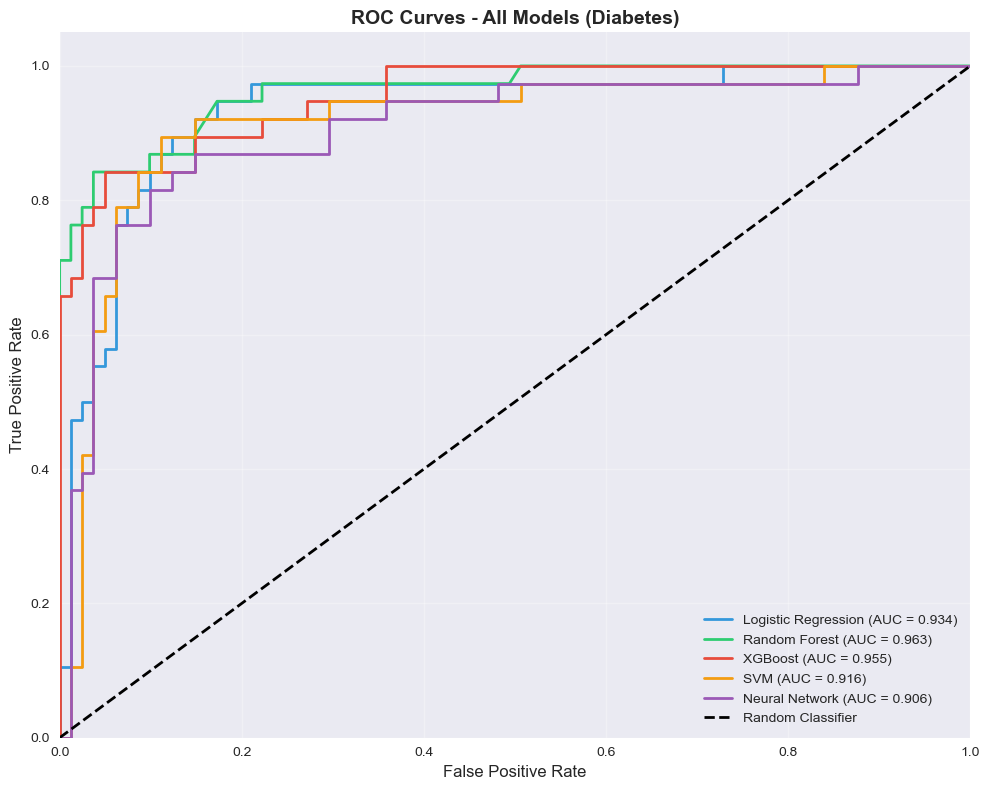

ROC Curve Complete!


In [11]:
# Step 5: ROC Curve
# Visual comparison of all models

print("=" * 50)
print("STEP 5: ROC CURVE")
print("=" * 50)

plt.figure(figsize=(10, 8))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c',
              '#f39c12', '#9b59b6']

for (name, result), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2,
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Diabetes)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC Curve Complete!")

STEP 6: BEST MODEL & CONFUSION MATRIX
Best Model: Random Forest
Accuracy:  0.8992
Precision: 0.8421
Recall:    0.8421
F1 Score:  0.8421
AUC ROC:   0.9628


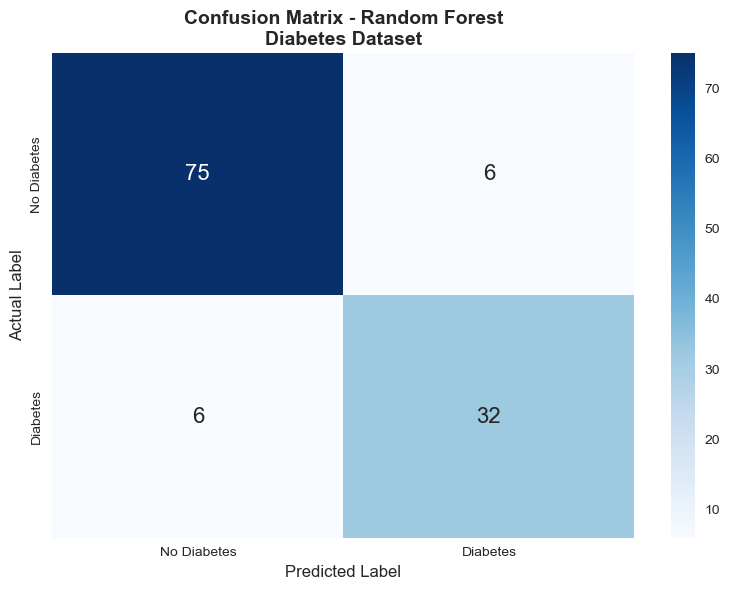


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.93      0.93      0.93        81
    Diabetes       0.84      0.84      0.84        38

    accuracy                           0.90       119
   macro avg       0.88      0.88      0.88       119
weighted avg       0.90      0.90      0.90       119



In [12]:
# Step 6: Best Model Selection & Confusion Matrix

print("=" * 50)
print("STEP 6: BEST MODEL & CONFUSION MATRIX")
print("=" * 50)

best_model_name = results_df['F1 Score'].idxmax()
best_model = results[best_model_name]['Model']
y_pred_best = results[best_model_name]['y_pred']

print(f"Best Model: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}\n'
          f'Diabetes Dataset',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=['No Diabetes', 'Diabetes']))

STEP 7: SHAP EXPLAINABILITY


<Figure size 1000x600 with 0 Axes>

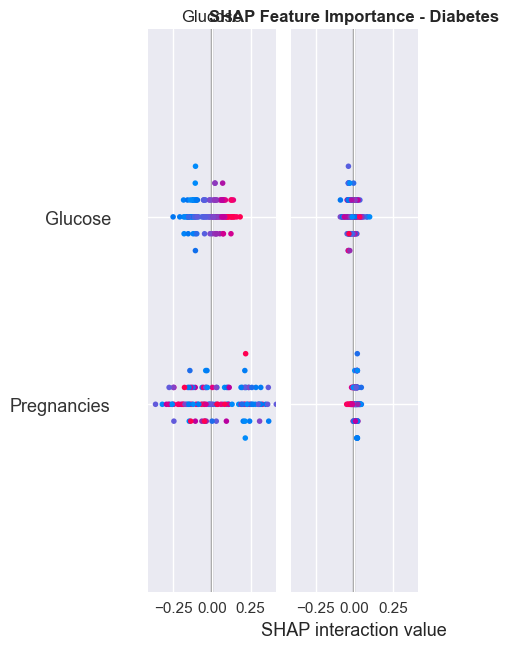

<Figure size 1000x600 with 0 Axes>

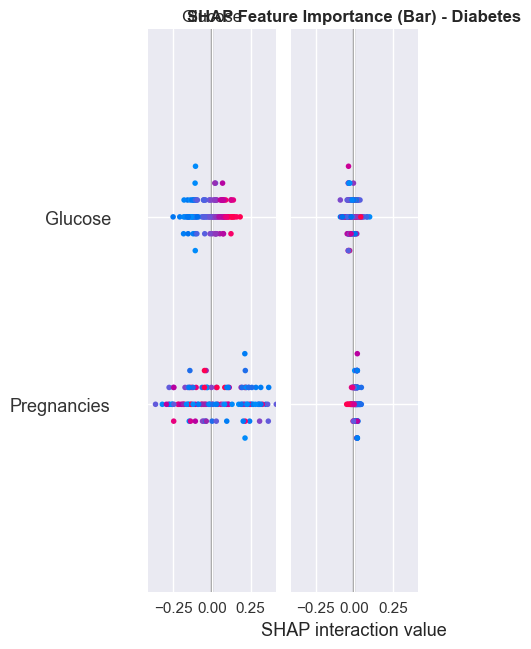

SHAP Analysis Complete!

Top Features by SHAP:
DiabetesPedigreeFunction    0.086057
Age                         0.086057
SkinThickness               0.083503
BloodPressure               0.083503
Pregnancies                 0.015332
Glucose                     0.015332
Insulin                     0.009944
BMI                         0.009944
dtype: float64


In [14]:
# Step 7: SHAP Explainability
# Explain why model made specific predictions

print("=" * 50)
print("STEP 7: SHAP EXPLAINABILITY")
print("=" * 50)

# Use Tree-based SHAP for RF and XGBoost
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.KernelExplainer(
        best_model.predict_proba,
        shap.sample(X_train, 100))

shap_values = explainer.shap_values(X_test)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# Plot 1: SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance - Diabetes',
          fontweight='bold')
plt.tight_layout()
plt.savefig('E:/HealthGuard_AI/reports/diabetes_shap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance (Bar) - Diabetes',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("SHAP Analysis Complete!")
print("\nTop Features by SHAP:")
shap_mean = np.abs(shap_vals).mean(axis=0).flatten()
n_features = len(X_train.columns)
shap_mean = shap_mean[:n_features]

shap_importance = pd.Series(
    shap_mean,
    index=X_train.columns
).sort_values(ascending=False)
print(shap_importance)

In [15]:
# Step 8: Save Best Model

print("=" * 50)
print("STEP 8: SAVE MODEL")
print("=" * 50)

model_path = "E:/HealthGuard_AI/models/saved/diabetes_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

# Verify
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:5])
print(f"Model: {best_model_name}")
print(f"Saved at: {model_path}")
print(f"Verification Predictions: {test_pred}")
print("Model Saved and Verified!")

STEP 8: SAVE MODEL
Model: Random Forest
Saved at: E:/HealthGuard_AI/models/saved/diabetes_model.pkl
Verification Predictions: [1 0 0 1 0]
Model Saved and Verified!


In [16]:
# Final Summary Report

print("=" * 60)
print("   DIABETES MODEL TRAINING - FINAL SUMMARY")
print("=" * 60)

print("\nCROSS VALIDATION RESULTS:")
print("-" * 40)
for name, cv in cv_results.items():
    print(f"{name}: {cv['Mean F1']:.4f} (+/- {cv['Std F1']:.4f})")

print("\nFINAL MODEL PERFORMANCE:")
print("-" * 40)
print(results_df.to_string())

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

print(f"\nModel saved: diabetes_model.pkl")
print("\nDiabetes Model Training Complete! ")
print("=" * 60)

   DIABETES MODEL TRAINING - FINAL SUMMARY

CROSS VALIDATION RESULTS:
----------------------------------------
Logistic Regression: 0.8831 (+/- 0.0187)
Random Forest: 0.9283 (+/- 0.0121)
XGBoost: 0.9370 (+/- 0.0089)
SVM: 0.9113 (+/- 0.0210)
Neural Network: 0.9190 (+/- 0.0171)

FINAL MODEL PERFORMANCE:
----------------------------------------
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.8655     0.7292  0.9211    0.8140   0.9340
Random Forest          0.8992     0.8421  0.8421    0.8421   0.9628
XGBoost                0.8992     0.8421  0.8421    0.8421   0.9545
SVM                    0.8824     0.8000  0.8421    0.8205   0.9159
Neural Network         0.8571     0.7561  0.8158    0.7848   0.9061

BEST MODEL: Random Forest
Accuracy:  0.8992
Precision: 0.8421
Recall:    0.8421
F1 Score:  0.8421
AUC ROC:   0.9628

Model saved: diabetes_model.pkl

Diabetes Model Training Complete! 
